# Notebook 07 — LDA Topic Modeling
**CMPE-255 | Mental Health & Crisis Signal Mining on Social Media**
**Owner: Ravikumar Komandur Narayanan**
**Environment: Google Colab**

---

### What this notebook does

1. **Coherence sweep** — fits LDA models for k ∈ {8, 10, 12, 15, 18, 20} topics
   and selects the optimal k by C_v coherence score.
2. **Final LDA model** — trains the best-k model with 15 passes.
3. **Topic probability vectors** — produces a (n_train × k) matrix of per-post
   topic probabilities; saved as `lda_topic_features.npz` for the EXP-3 LDA
   ablation in Notebook 05.
4. **Topic × class cross-tabulation** — heatmap showing which topics dominate
   each mental-health class.
5. **pyLDAvis visualisation** — interactive HTML for in-notebook exploration.
6. **Per-class word clouds** — one cloud per disorder, coloured by class colour.

### Prerequisites
Run **Notebook 02** (Data Preprocessing) first.

Required files in `DRIVE_ROOT/data/processed/`:
- `train.parquet`

Output files written by this notebook:
- `artifacts/lda_model.joblib` — trained gensim LDA model
- `artifacts/lda_topic_features.npz` — topic probability matrix
- `artifacts/lda_topic_mapping.json` — topic_id → top-10 words
- `figures/lda_coherence.png` — coherence sweep plot
- `figures/lda_topic_class_heatmap.png` — topic × class heatmap
- `figures/lda_topics.html` — interactive pyLDAvis
- `figures/lda_wordcloud_<class>.png` — per-class word clouds

### After running this notebook
Go back to **Notebook 05** (XGBoost Tuning), set `USE_LDA_FEATURES = True` in
Cell 3, and re-run to add LDA topic probability features to the combined feature
matrix (EXP-3 LDA ablation).

In [1]:
# ============================================================
# CELL 1 — Package Installation
# ------------------------------------------------------------
# gensim    : topic modelling library (LDA + coherence measures)
# pyLDAvis  : interactive visualisation of LDA topic structure
# wordcloud : word cloud generation from class-level text
# nltk      : stop-word list
#
# All other packages (numpy, pandas, matplotlib, scipy) are
# pre-installed in Colab.
# ============================================================
!pip install gensim pyLDAvis wordcloud nltk --quiet
print('Packages ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 181.2 MB/s eta 0:00:00
Packages ready.


In [2]:
# ============================================================
# CELL 2 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [3]:
# ============================================================
# CELL 3 — Project Path Configuration
# ------------------------------------------------------------
# Edit DRIVE_ROOT to match your Google Drive folder name.
# ============================================================
from pathlib import Path

# --- EDIT THIS LINE if your folder has a different name ---
DRIVE_ROOT = Path('/content/drive/MyDrive/Guna_CMPE_255_Project')
# ----------------------------------------------------------

DATA_DIR      = DRIVE_ROOT / 'data' / 'processed'  # train.parquet
ARTIFACTS_DIR = DRIVE_ROOT / 'artifacts'            # LDA model, feature vectors
FIGURES_DIR   = DRIVE_ROOT / 'figures'              # coherence plot, heatmap, word clouds

for d in [ARTIFACTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Verify required input files are present
required = [
    DATA_DIR / 'train.parquet',
    DATA_DIR / 'test.parquet',   # needed for test-set LDA topic vectors (NB-05 ablation)
]
print('Input file check:')
for p in required:
    print(f'  {"✅" if p.exists() else "❌ MISSING"}  {p.name}')

Input file check:
  ✅  train.parquet
  ✅  test.parquet


In [4]:
# ============================================================
# CELL 4 — Standard Library Imports
# ============================================================
import random
import os
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib

# gensim — LDA topic model and coherence scoring
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

# pyLDAvis — interactive topic visualisation
import pyLDAvis
import pyLDAvis.gensim_models

# Word cloud generation
from wordcloud import WordCloud

# NLTK stop-word list
import nltk

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'gensim version   : {gensim.__version__}')
print('All imports successful.')

gensim version   : 4.4.0
All imports successful.


In [5]:
# ============================================================
# CELL 5 — Project Constants  (inlined from utils/common.py)
# ============================================================

RANDOM_SEED = 42

def seed_everything(seed=RANDOM_SEED):
    """Seed Python built-ins and NumPy for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything()

# Integer label → disorder name mapping
LABEL_MAP = {
    0: 'Stress',
    1: 'Depression',
    2: 'Bipolar Disorder',
    3: 'Personality Disorder',
    4: 'Anxiety',
}
CLASS_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

# Consistent colour palette — same as all other notebooks
CLASS_COLORS = {
    'Stress':               '#E74C3C',
    'Depression':           '#3498DB',
    'Bipolar Disorder':     '#9B59B6',
    'Personality Disorder': '#E67E22',
    'Anxiety':              '#2ECC71',
}

print(f'RANDOM_SEED = {RANDOM_SEED}')
print(f'Classes     = {CLASS_NAMES}')

RANDOM_SEED = 42
Classes     = ['Stress', 'Depression', 'Bipolar Disorder', 'Personality Disorder', 'Anxiety']


In [6]:
# ============================================================
# CELL 6 — Download NLTK Stop-words
# ------------------------------------------------------------
# We need the English stop-word list for LDA preprocessing and
# word cloud generation.  The try/except avoids re-downloading
# if the word list is already cached in the Colab instance.
# ============================================================
try:
    from nltk.corpus import stopwords
    _sw = stopwords.words('english')
except LookupError:
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    _sw = stopwords.words('english')

print(f'NLTK stop-words loaded — count: {len(_sw)}')

NLTK stop-words loaded — count: 198


## 1. Load Training Data

In [7]:
# ============================================================
# CELL 7 — Load Training and Test Data
# ============================================================

train_df = pd.read_parquet(DATA_DIR / 'train.parquet')
texts    = train_df['text'].tolist()
labels   = train_df['label'].values

# Also load test set so we can build test-set topic vectors for NB-05 LDA ablation.
# The LDA dictionary will be fit on training texts only (no leakage).
# test_texts are only TRANSFORMED through the pre-fit dictionary, never used to fit it.
test_df    = pd.read_parquet(DATA_DIR / 'test.parquet')
test_texts = test_df['text'].tolist()

print(f'Training rows : {len(texts):,}')
print(f'Test rows     : {len(test_texts):,}')
print('\nClass distribution (train):')
print(
    pd.Series(labels)
    .map(LABEL_MAP)
    .value_counts()
    .sort_index()
    .to_string()
)

Training rows : 3,500
Test rows     : 876

Class distribution (train):
Anxiety                 745
Bipolar Disorder        647
Depression              776
Personality Disorder    713
Stress                  619


## 2. Text Preprocessing for LDA

LDA requires a bag-of-words corpus — word order is discarded.
The preprocessing pipeline:
1. Lowercase + strip non-alphabetic characters.
2. Remove English stop-words and a set of domain-specific filler words
   (high-frequency first-person and hedging terms that appear in all
   classes and would dominate every topic if kept).
3. Keep only tokens with length ≥ 3.

We do **not** use lemmatisation here because the gensim coherence scorer
works better with surface forms for short Reddit posts.

In [8]:
# ============================================================
# CELL 8 — LDA Text Preprocessing
# ============================================================

# Domain-specific filler words that appear in every mental-health class
# and would dominate topics without contributing class-discriminative signal.
DOMAIN_STOPWORDS = {
    'feel', 'like', 'people', 'really', 'im', 'get', 'one', 'would', 'could',
    'know', 'want', 'think', 'time', 'dont', 'ive', 'even', 'make', 'way',
    'still', 'much', 'going', 'never', 'always', 'things', 'thing', 'back',
}
ALL_STOPWORDS = set(_sw) | DOMAIN_STOPWORDS


def preprocess_for_lda(texts):
    """
    Tokenise each document, remove stop-words, and filter short tokens.

    Parameters
    ----------
    texts : list of raw post strings

    Returns
    -------
    list of token lists (one list per document)
    """
    tokenized = []
    for doc in texts:
        doc    = doc.lower()                        # case normalisation
        doc    = re.sub(r'[^a-z\s]', ' ', doc)     # remove all non-alpha characters
        tokens = [
            t for t in doc.split()
            if t not in ALL_STOPWORDS and len(t) >= 3  # drop stop-words and short tokens
        ]
        tokenized.append(tokens)
    return tokenized


print('Preprocessing texts for LDA...')
tokenized_texts      = preprocess_for_lda(texts)
tokenized_test_texts = preprocess_for_lda(test_texts)   # same pipeline — no refit
print(f'Done.')
print(f'  Train tokens example (doc 0): {tokenized_texts[0][:15]}')
print(f'  Test  tokens example (doc 0): {tokenized_test_texts[0][:15]}')

Preprocessing texts for LDA...
Done.
  Train tokens example (doc 0): ['turns', 'reached', 'months', 'without', 'days', 'ago', 'notice', 'longest', 'clean', 'almost', 'years', 'usually', 'proud', 'every', 'milestone']
  Test  tokens example (doc 0): ['spent', 'lot', 'thinking', 'ended', 'disorder', 'constantly', 'reviewing', 'analyzing', 'past', 'memories', 'trying', 'find', 'pinpoint', 'exact', 'event']


In [9]:
# ============================================================
# CELL 9 — Build gensim Dictionary and Bag-of-Words Corpus
# ------------------------------------------------------------
# Dictionary maps each unique token to an integer ID.
# filter_extremes removes:
#   no_below=5   : tokens appearing in fewer than 5 documents (rare noise)
#   no_above=0.7 : tokens appearing in more than 70% of documents (too common)
# This pruning reduces the vocabulary to the most informative words.
# ============================================================

dictionary = corpora.Dictionary(tokenized_texts)
dictionary.filter_extremes(no_below=5, no_above=0.7)

# doc2bow converts each token list to [(word_id, count), ...] format
corpus      = [dictionary.doc2bow(doc) for doc in tokenized_texts]

# IMPORTANT: test corpus uses the SAME pre-fit dictionary (transform only).
# Calling filter_extremes or fit again on test text would be data leakage.
test_corpus = [dictionary.doc2bow(doc) for doc in tokenized_test_texts]

print(f'Vocabulary size after filtering : {len(dictionary):,} tokens')
print(f'Train corpus documents          : {len(corpus):,}')
print(f'Test  corpus documents          : {len(test_corpus):,}')

Vocabulary size after filtering : 4,325 tokens
Train corpus documents          : 3,500
Test  corpus documents          : 876


## 3. Coherence Sweep — k ∈ {8, 10, 12, 15, 18, 20}

**C_v coherence** measures how semantically related the top words of each
topic are, using word co-occurrence statistics from the training corpus.
Higher C_v → more coherent (interpretable) topics.

We fit one LDA model per k value and record its C_v score to identify
the optimal number of topics. The k that maximises C_v is selected for
the final model.

> ⏱ **Runtime:** each k takes ~2–3 min on a free Colab CPU.
> The full sweep (6 values) takes ~15–20 minutes.

In [10]:
# ============================================================
# CELL 10 — Coherence Sweep
# ============================================================

K_CANDIDATES      = [8, 10, 12, 15, 18, 20]  # topic counts to evaluate
coherence_records = []

print(f'Starting coherence sweep over k = {K_CANDIDATES}')
print('(Each k takes ~2-3 min — total ~15-20 min on free Colab CPU)\n')

for k in K_CANDIDATES:
    print(f'  Fitting LDA with k={k} topics...')

    # alpha='auto' and eta='auto' let gensim learn the Dirichlet priors
    # from the data rather than using fixed symmetric priors.
    lda_tmp = LdaModel(
        corpus=corpus,
        num_topics=k,
        id2word=dictionary,
        random_state=RANDOM_SEED,
        passes=15,               # number of full passes through the corpus
        alpha='auto',            # document-topic concentration prior (learned)
        eta='auto',              # topic-word concentration prior (learned)
    )

    # C_v coherence: co-occurrence-based semantic similarity of top-10 words per topic
    cm_cv    = CoherenceModel(
        model=lda_tmp,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v',
    )
    cv_score = cm_cv.get_coherence()
    coherence_records.append({'k': k, 'c_v': cv_score})
    print(f'    k={k:2d}  →  C_v = {cv_score:.4f}')

coherence_df = pd.DataFrame(coherence_records)
print('\nCoherence sweep results:')
print(coherence_df.to_string(index=False))

Starting coherence sweep over k = [8, 10, 12, 15, 18, 20]
(Each k takes ~2-3 min — total ~15-20 min on free Colab CPU)

  Fitting LDA with k=8 topics...
    k= 8  →  C_v = 0.3764
  Fitting LDA with k=10 topics...
    k=10  →  C_v = 0.3624
  Fitting LDA with k=12 topics...
    k=12  →  C_v = 0.3850
  Fitting LDA with k=15 topics...
    k=15  →  C_v = 0.3543
  Fitting LDA with k=18 topics...
    k=18  →  C_v = 0.3749
  Fitting LDA with k=20 topics...
    k=20  →  C_v = 0.3580

Coherence sweep results:
 k      c_v
 8 0.376363
10 0.362401
12 0.384975
15 0.354277
18 0.374890
20 0.358001


Optimal k = 12  (C_v = 0.3850)


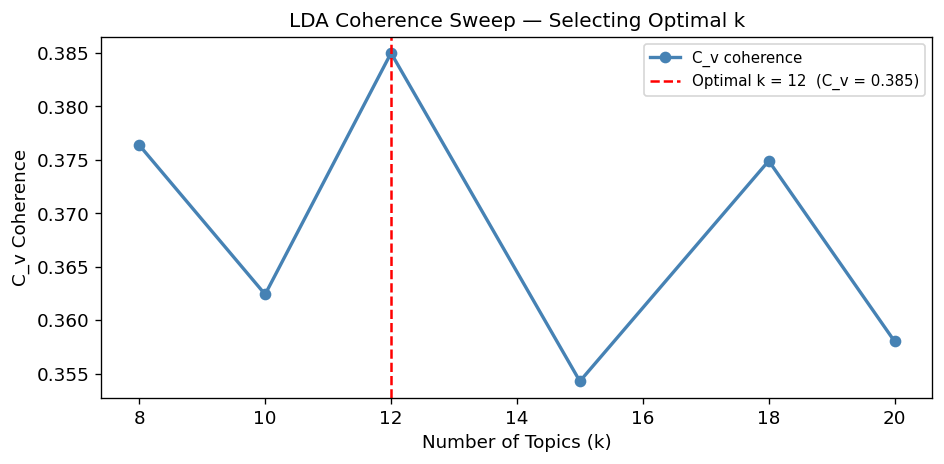

Saved → /content/drive/MyDrive/Guna_CMPE_255_Project/figures/lda_coherence.png


In [11]:
# ============================================================
# CELL 11 — Coherence Plot + Select Optimal k
# ============================================================

# The optimal k maximises C_v coherence
OPTIMAL_K   = int(coherence_df.loc[coherence_df['c_v'].idxmax(), 'k'])
OPTIMAL_CV  = coherence_df['c_v'].max()
print(f'Optimal k = {OPTIMAL_K}  (C_v = {OPTIMAL_CV:.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    coherence_df['k'], coherence_df['c_v'],
    marker='o', linewidth=2, color='steelblue', label='C_v coherence'
)
ax.axvline(
    OPTIMAL_K, linestyle='--', color='red', linewidth=1.5,
    label=f'Optimal k = {OPTIMAL_K}  (C_v = {OPTIMAL_CV:.3f})'
)
ax.set_xlabel('Number of Topics (k)', fontsize=11)
ax.set_ylabel('C_v Coherence', fontsize=11)
ax.set_title('LDA Coherence Sweep — Selecting Optimal k', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'lda_coherence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/lda_coherence.png')

## 4. Final LDA Model

We retrain a single LDA model with the optimal k selected above.
Training on the full corpus (not just a coherence evaluation sample)
produces better topic-word distributions.

In [12]:
# ============================================================
# CELL 12 — Train Final LDA Model at Optimal k
# ============================================================

print(f'Training final LDA model with k={OPTIMAL_K} topics...')
print('(passes=15 — takes ~3–5 min on Colab CPU)')

lda_model = LdaModel(
    corpus=corpus,
    num_topics=OPTIMAL_K,
    id2word=dictionary,
    random_state=RANDOM_SEED,
    passes=15,
    alpha='auto',
    eta='auto',
)

# Persist model to Drive so it can be loaded in other notebooks without retraining
joblib.dump(lda_model, ARTIFACTS_DIR / 'lda_model.joblib')
print(f'LDA model saved → {ARTIFACTS_DIR}/lda_model.joblib')

# Display the top-15 words for each topic
print(f'\nTop-15 words per topic (k={OPTIMAL_K}):')
for topic_id in range(OPTIMAL_K):
    top_words = [w for w, _ in lda_model.show_topic(topic_id, topn=15)]
    print(f'  Topic {topic_id:2d} : {top_words}')

Training final LDA model with k=12 topics...
(passes=15 — takes ~3–5 min on Colab CPU)
LDA model saved → /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/lda_model.joblib

Top-15 words per topic (k=12):
  Topic  0 : ['life', 'thoughts', 'something', 'anyone', 'mind', 'anxiety', 'others', 'experience', 'also', 'able', 'self', 'stress', 'sometimes', 'emotions', 'start']
  Topic  1 : ['sleep', 'stress', 'anxiety', 'feeling', 'last', 'day', 'got', 'started', 'pain', 'also', 'symptoms', 'heart', 'bad', 'body', 'night']
  Topic  2 : ['work', 'job', 'stress', 'need', 'school', 'working', 'day', 'keep', 'help', 'week', 'anxiety', 'life', 'year', 'good', 'new']
  Topic  3 : ['anxiety', 'take', 'feeling', 'anyone', 'meds', 'day', 'help', 'taking', 'days', 'panic', 'started', 'doctor', 'work', 'anything', 'also']
  Topic  4 : ['something', 'someone', 'anyone', 'told', 'else', 'said', 'talk', 'need', 'anxiety', 'say', 'got', 'tell', 'started', 'right', 'room']
  Topic  5 : ['poll', 'reddit',

## 5. Topic Probability Vectors

For each training document we query the LDA model for its topic distribution
— a length-k probability vector where element i is the weight of topic i in
that document.

These vectors are stacked into a (n_train × k) matrix and saved as
`lda_topic_features.npz`.  Notebook 05 loads this file when
`USE_LDA_FEATURES = True` to add LDA features to the XGBoost input matrix.

In [13]:
# ============================================================
# CELL 13 — Build and Save Topic Probability Matrices (Train + Test)
# ------------------------------------------------------------
# NB-05 (XGBoost) loads lda_topic_features.npz when USE_LDA_FEATURES=True.
# It expects TWO arrays in the file:
#   X_train : (n_train, k) — one topic-probability vector per training post
#   X_test  : (n_test,  k) — one topic-probability vector per test post
#
# The test matrix MUST be built here (not in NB-05) because this notebook
# holds the fitted LDA model and the fitted gensim Dictionary.
# The dictionary is never refit on test data — we just call doc2bow() with
# the training vocabulary, so out-of-vocabulary test tokens are silently
# dropped.  This is the correct no-leakage approach.
# ============================================================

def build_topic_matrix(bow_corpus, lda_mdl, n_topics):
    # Build a (n_docs, n_topics) float32 matrix of LDA topic probabilities.
    # Documents with no in-vocabulary tokens keep a zero row.
    mat = np.zeros((len(bow_corpus), n_topics), dtype=np.float32)
    for i, bow in enumerate(bow_corpus):
        topic_probs = dict(
            lda_mdl.get_document_topics(bow, minimum_probability=0.0)
        )
        for topic_id, prob in topic_probs.items():
            mat[i, topic_id] = prob
    return mat


print(f'Building train topic matrix  ({len(corpus):,} x {OPTIMAL_K})...')
topic_matrix = build_topic_matrix(corpus, lda_model, OPTIMAL_K)

print(f'Building test  topic matrix  ({len(test_corpus):,} x {OPTIMAL_K})...')
test_topic_matrix = build_topic_matrix(test_corpus, lda_model, OPTIMAL_K)

# ── Save all arrays in one npz file ──────────────────────────────────────────
# Keys stored:
#   topic_features — canonical name (used in NB-07 cross-tabulation below)
#   X_train        — alias expected by NB-05 loading code
#   X_test         — test-set vectors for NB-05 LDA ablation  ← NEW key
np.savez(
    ARTIFACTS_DIR / 'lda_topic_features.npz',
    topic_features=topic_matrix,
    X_train=topic_matrix,           # NB-05 reads 'X_train' key
    X_test=test_topic_matrix,       # NB-05 reads 'X_test'  key — was missing before
)
print(f'\nSaved -> {ARTIFACTS_DIR}/lda_topic_features.npz')
print(f'  X_train shape : {topic_matrix.shape}')
print(f'  X_test  shape : {test_topic_matrix.shape}')

# ── Save topic_id -> top-10 words mapping ────────────────────────────────────
topic_mapping = {
    str(tid): [w for w, _ in lda_model.show_topic(tid, topn=10)]
    for tid in range(OPTIMAL_K)
}
with open(ARTIFACTS_DIR / 'lda_topic_mapping.json', 'w') as f:
    json.dump(topic_mapping, f, indent=2)
print(f'Saved -> {ARTIFACTS_DIR}/lda_topic_mapping.json')

# ── Sanity check: rows should sum to ~1.0 ────────────────────────────────────
for name, mat in [('train', topic_matrix), ('test', test_topic_matrix)]:
    rs        = mat.sum(axis=1)
    valid_rs  = rs[rs > 0]
    zero_rows = (rs == 0).sum()
    print(f'  {name} row-sum: mean={valid_rs.mean():.4f}'
          f'  min={rs.min():.4f}  max={rs.max():.4f}'
          f'  zero-rows={zero_rows} ({zero_rows/len(rs)*100:.1f}% have no in-vocab tokens)')

Building train topic matrix  (3,500 x 12)...
Building test  topic matrix  (876 x 12)...

Saved -> /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/lda_topic_features.npz
  X_train shape : (3500, 12)
  X_test  shape : (876, 12)
Saved -> /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/lda_topic_mapping.json
  train row-sum: mean=1.0000  min=1.0000  max=1.0000  zero-rows=0 (0.0% have no in-vocab tokens)
  test row-sum: mean=1.0000  min=1.0000  max=1.0000  zero-rows=0 (0.0% have no in-vocab tokens)


## 6. Topic × Class Cross-Tabulation

For each class we compute the **mean topic probability** across all
documents in that class.  The resulting (5 × k) heatmap reveals which
topics are characteristically associated with which mental-health
condition — useful for interpretability analysis in the paper.

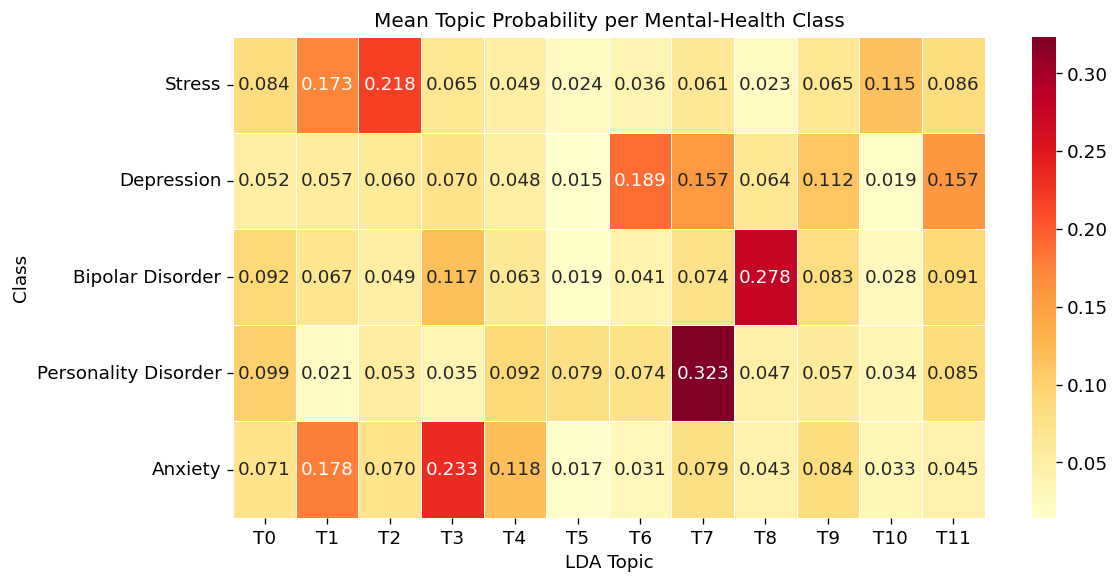

Saved → /content/drive/MyDrive/Guna_CMPE_255_Project/figures/lda_topic_class_heatmap.png


In [14]:
# ============================================================
# CELL 14 — Topic × Class Mean Probability Heatmap
# ============================================================

# Build mean topic probability per class
mean_topic_per_class = np.zeros((len(CLASS_NAMES), OPTIMAL_K), dtype=np.float32)
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = labels == cls_idx           # boolean mask for this class's documents
    if mask.sum() > 0:
        mean_topic_per_class[cls_idx] = topic_matrix[mask].mean(axis=0)

heatmap_df = pd.DataFrame(
    mean_topic_per_class,
    index=CLASS_NAMES,
    columns=[f'T{i}' for i in range(OPTIMAL_K)],
)

# Dynamic figure width so column labels don't overlap for larger k values
fig_width = max(10, OPTIMAL_K * 0.8)
fig, ax   = plt.subplots(figsize=(fig_width, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.4,
)
ax.set_title('Mean Topic Probability per Mental-Health Class', fontsize=12)
ax.set_xlabel('LDA Topic', fontsize=11)
ax.set_ylabel('Class', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'lda_topic_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/lda_topic_class_heatmap.png')

## 7. pyLDAvis Visualisation

pyLDAvis provides an interactive 2-D topic map where:
- **Circle size** = topic frequency (proportion of corpus tokens assigned to that topic).
- **Distance between circles** = topic dissimilarity (overlapping circles share vocabulary).
- **Right panel** = top-30 token relevance for the selected topic.

The visualisation is saved as a standalone HTML file that can be opened in any browser.

In [15]:
# ============================================================
# CELL 15 — pyLDAvis Interactive Visualisation
# ============================================================

# Enable inline rendering inside the Colab notebook cell
pyLDAvis.enable_notebook()

# Prepare the visualisation data structure from gensim model objects
vis_data = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)

# Save as a self-contained HTML file (works offline, shareable with supervisors)
html_path = FIGURES_DIR / 'lda_topics.html'
pyLDAvis.save_html(vis_data, str(html_path))
print(f'Saved → {html_path}')

# Render inline in the notebook
pyLDAvis.display(vis_data)

Saved → /content/drive/MyDrive/Guna_CMPE_255_Project/figures/lda_topics.html


## 8. Per-Class Word Clouds

One word cloud per class, generated from the raw text of all training
posts in that class.  Each cloud is tinted with the class colour defined
in our project palette, making the five clouds visually distinguishable
at a glance.

Generating word clouds...


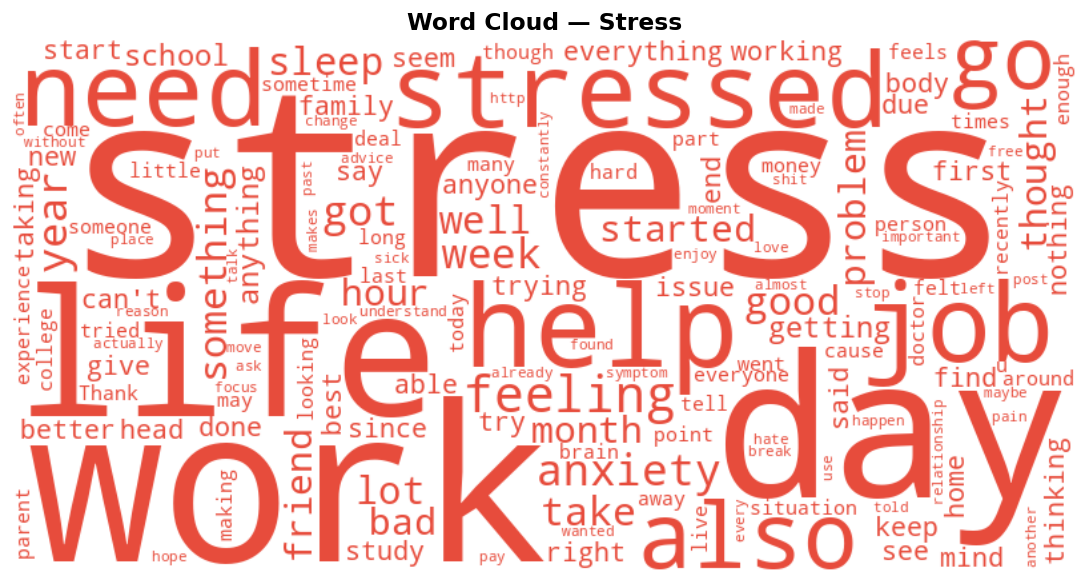

  Saved → lda_wordcloud_stress.png


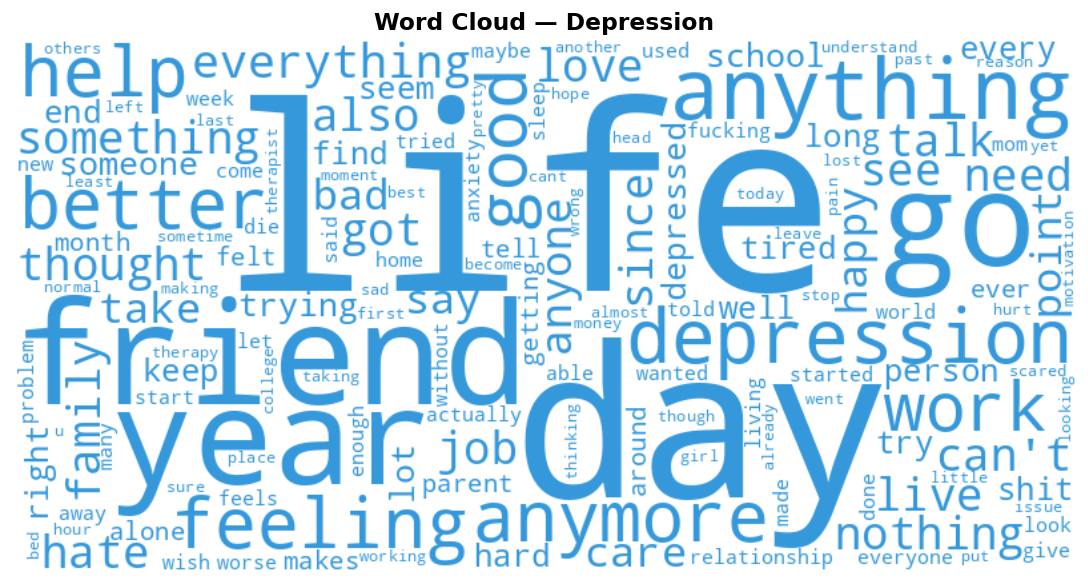

  Saved → lda_wordcloud_depression.png


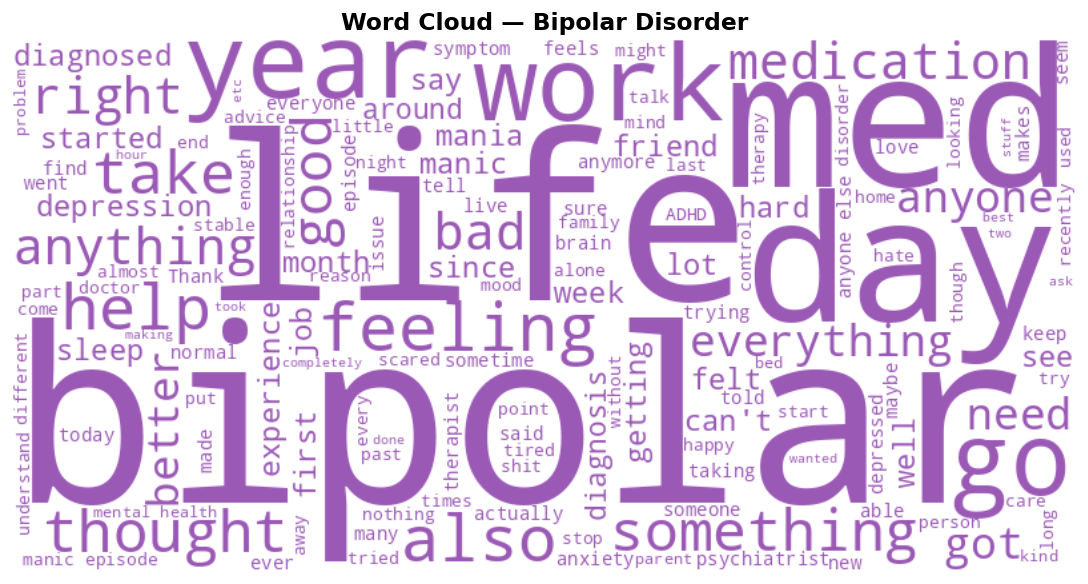

  Saved → lda_wordcloud_bipolar_disorder.png


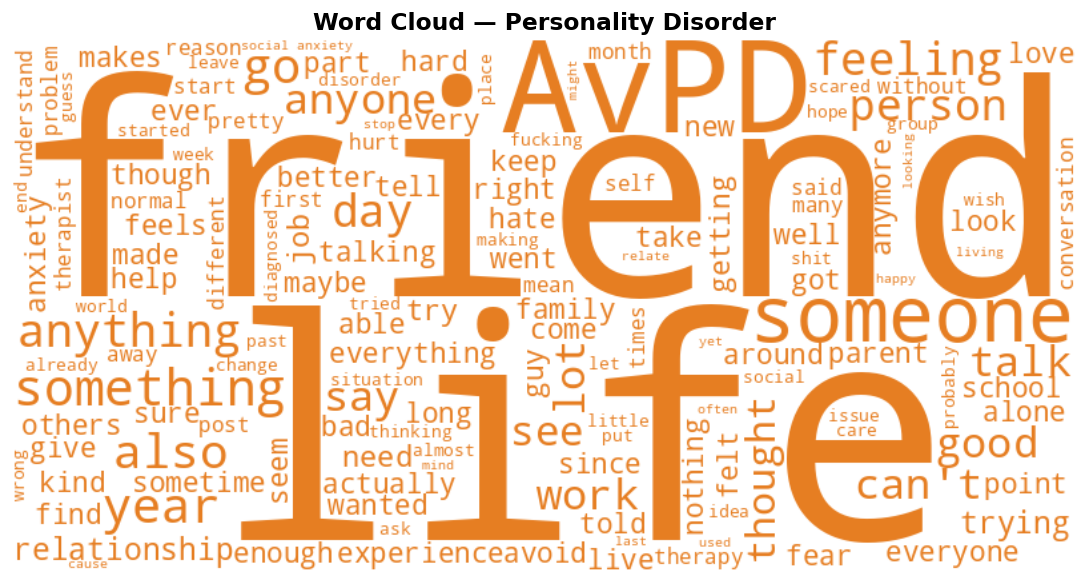

  Saved → lda_wordcloud_personality_disorder.png


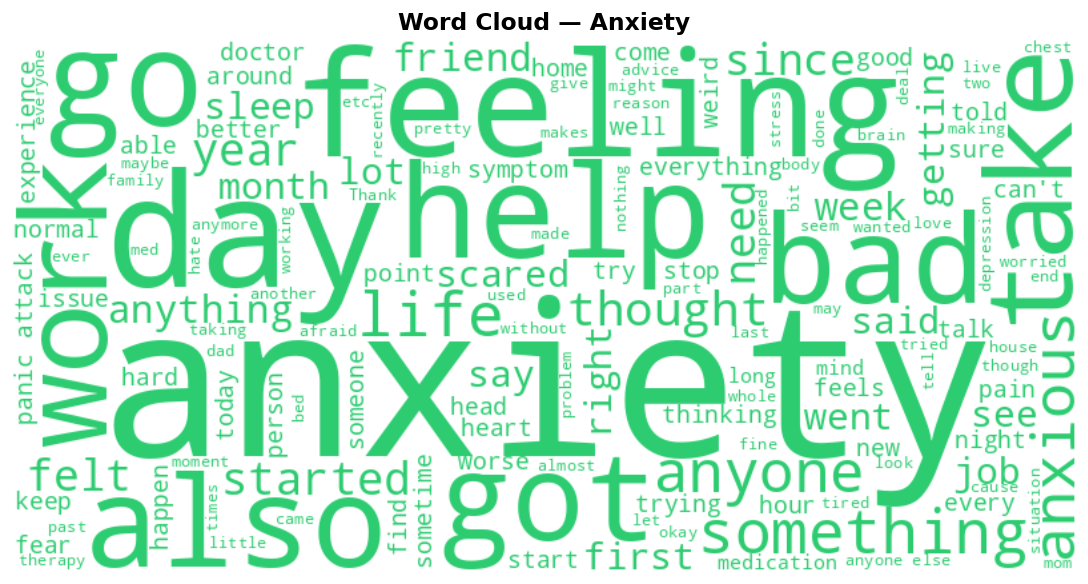

  Saved → lda_wordcloud_anxiety.png

All word clouds saved.


In [16]:
# ============================================================
# CELL 16 — Per-Class Word Clouds
# ============================================================

print('Generating word clouds...')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    # Collect all texts belonging to this class
    mask      = labels == cls_idx
    cls_texts = [texts[i] for i in range(len(texts)) if mask[i]]

    if not cls_texts:
        print(f'  {cls_name}: no texts — skipping')
        continue

    combined = ' '.join(cls_texts)

    # Create a colour function pinned to this class's palette colour
    # so every word in the cloud is rendered in the class colour.
    cls_color = CLASS_COLORS.get(cls_name, '#888888')

    def make_color_func(color):
        def _color_func(*args, **kwargs):
            return color
        return _color_func

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=ALL_STOPWORDS,   # reuse the same stop-word set as LDA preprocessing
        max_words=150,             # limit to top-150 tokens by frequency
        color_func=make_color_func(cls_color),
        random_state=RANDOM_SEED,
    ).generate(combined)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {cls_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()

    safe_name = cls_name.lower().replace(' ', '_')
    fname     = FIGURES_DIR / f'lda_wordcloud_{safe_name}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {fname.name}')

print('\nAll word clouds saved.')

In [17]:
# ============================================================
# CELL 17 — Next Steps
# ============================================================

print('Notebook 07 complete.')
print()
print('Artifacts saved to DRIVE_ROOT/artifacts/:')
print(f'  lda_model.joblib        — trained LDA model (k={OPTIMAL_K} topics)')
print( '  lda_topic_features.npz  — X_train AND X_test topic probability matrices')
print( '  lda_topic_mapping.json  — topic -> top-10 words lookup')
print()
print('Figures saved to DRIVE_ROOT/figures/:')
print( '  lda_coherence.png              — coherence sweep')
print( '  lda_topic_class_heatmap.png    — topic x class heatmap')
print( '  lda_topics.html                — pyLDAvis interactive viewer')
print( '  lda_wordcloud_<class>.png      — per-class word clouds')
print()
print('--- Next steps --------------------------------------------------')
print('1. Open Notebook 05 (XGBoost Tuning).')
print('   Set USE_LDA_FEATURES = True in Cell 3.')
print('   Re-run from Cell 3 onwards to produce the EXP-3 LDA ablation row.')
print('   Both X_train and X_test topic vectors are now saved in')
print('   lda_topic_features.npz, so the full train+test evaluation works.')
print('2. Run Notebook 08 (Model Evaluation & Comparison)')
print('   to see the full cross-experiment summary table.')

Notebook 07 complete.

Artifacts saved to DRIVE_ROOT/artifacts/:
  lda_model.joblib        — trained LDA model (k=12 topics)
  lda_topic_features.npz  — X_train AND X_test topic probability matrices
  lda_topic_mapping.json  — topic -> top-10 words lookup

Figures saved to DRIVE_ROOT/figures/:
  lda_coherence.png              — coherence sweep
  lda_topic_class_heatmap.png    — topic x class heatmap
  lda_topics.html                — pyLDAvis interactive viewer
  lda_wordcloud_<class>.png      — per-class word clouds

--- Next steps --------------------------------------------------
1. Open Notebook 05 (XGBoost Tuning).
   Set USE_LDA_FEATURES = True in Cell 3.
   Re-run from Cell 3 onwards to produce the EXP-3 LDA ablation row.
   Both X_train and X_test topic vectors are now saved in
   lda_topic_features.npz, so the full train+test evaluation works.
2. Run Notebook 08 (Model Evaluation & Comparison)
   to see the full cross-experiment summary table.
